# 13 — Aplicación a las 3 flotas: análisis económico

**Proyecto:** RepostaPro — Optimización del repostaje en flotas comerciales  
**Autor:** Víctor González Martín  
**Notebook:** 13 — Aplicación a 3 perfiles de flota

## Objetivo del notebook

Aplicar el sistema de optimización validado a tres perfiles de flota representativos del sector logístico español. Cuantificar el ahorro económico que aporta el sistema RepostaPro frente a un repostaje no optimizado.

## Perfiles de flota

Los parámetros operacionales se basan en datos publicados por el **Observatorio de Costes del Transporte de Mercancías por Carretera** del Ministerio de Transportes y Movilidad Sostenible (MITMA, antes Ministerio de Fomento), referencia oficial del sector logístico español.

### Flota 1 — Mensajería urbana Madrid

| Parámetro | Valor |
|---|---|
| Vehículo | Furgoneta diésel |
| Tamaño flota | 30 vehículos |
| Base | Vallecas (40.3925, -3.665) |
| Consumo | 10 L/100km |
| Recorrido diario | 150 km |
| Consumo diario | 15 L |
| Repostaje | cada 3 días, 50 L |
| Radio búsqueda | 5 km |

### Flota 2 — Transporte interurbano regional

| Parámetro | Valor |
|---|---|
| Vehículo | Camión rígido |
| Tamaño flota | 15 vehículos |
| Base | Coslada, polígono logístico (40.4239, -3.4836) |
| Consumo | 28 L/100km |
| Recorrido diario | 400 km |
| Consumo diario | 112 L |
| Repostaje | diario, 150 L |
| Radio búsqueda | 15 km |

### Flota 3 — Transporte largo recorrido peninsular

| Parámetro | Valor |
|---|---|
| Vehículo | Tráiler articulado |
| Tamaño flota | 8 vehículos (3 a Barcelona, 3 a Sevilla, 2 a Bilbao) |
| Base | Madrid (40.4168, -3.7038) |
| Consumo | 35 L/100km |
| Capacidad depósito | 600 L |
| Nivel inicial | 150 L (25% del depósito) |
| Repostaje en ruta | 400 L |
| Radio búsqueda | 10 km/waypoint |

## Métricas de evaluación

1. **Ahorro vs naive**: diferencia entre repostar en la mejor estación vs la peor en el radio.
2. **Ahorro mensual y anual** extrapolado.
3. **Coste evitado total** del sistema.

In [1]:
# Configuración del entorno
import sys
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.family"] = "Calibri"
plt.rcParams["font.size"] = 11
sns.set_style("whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)

# Añadir raíz del proyecto al sys.path
RAIZ_PROYECTO = Path("..").resolve()
if str(RAIZ_PROYECTO) not in sys.path:
    sys.path.insert(0, str(RAIZ_PROYECTO))

# Importar funciones de optimización
from src.modelos import (distancia_haversine,encontrar_estaciones_cercanas,optimizar_repostaje_estacionario,optimizar_repostaje_ruta)

# Rutas
CARPETA_RESULTADOS = Path("../outputs/resultados_modelos")
CARPETA_FIGURAS = Path("../outputs/figures")

# Cargar predicciones del modelo de producción (pre-shock)
df_pred = pd.read_parquet(CARPETA_RESULTADOS / "predicciones_validacion_modelo_produccion.parquet")
df_pred["fecha"] = pd.to_datetime(df_pred["fecha"])

# Definir periodo de análisis (7 días de validación)
fechas_validacion = pd.date_range(start="2026-06-15", end="2026-06-21", freq="D")

# Días laborables del periodo (lunes a viernes)
dias_laborables = [f for f in fechas_validacion if f.dayofweek < 5]

print(f"Configuración completa")
print(f"Período de análisis: 15-21 jun 2026 ({len(fechas_validacion)} días totales, {len(dias_laborables)} laborables)")
print(f"Predicciones disponibles: {len(df_pred):,} filas")

Configuración completa
Período de análisis: 15-21 jun 2026 (7 días totales, 5 laborables)
Predicciones disponibles: 154,976 filas


## Flota 1 — Mensajería urbana (Vallecas, Madrid)

Aplicamos el sistema a 30 furgonetas con base en Vallecas. Cada furgoneta reposta 50 litros de Gasóleo A cada 3 días. Calculamos el ahorro durante el período de validación y extrapolamos a totales mensuales/anuales.

In [2]:
# FLOTA 1 — Mensajería urbana
print(">>> FLOTA 1: Mensajería urbana · Vallecas (Madrid)")
print("=" * 70)

# Parámetros
flota1 = {
    "nombre": "Mensajería urbana",
    "n_vehiculos": 30,
    "lat_base": 40.3925,
    "lon_base": -3.6650,
    "radio_km": 5,
    "consumo_l_km": 0.10,
    "litros_repostaje": 50,
    "carburante": "Gasóleo A",
    "frecuencia_repostaje_dias": 3,  # cada 3 días
    "dias_operacion_mes": 22,        # días laborables/mes
}

# Calcular operaciones por mes
operaciones_mes_vehiculo = flota1["dias_operacion_mes"] / flota1["frecuencia_repostaje_dias"]
operaciones_mes_flota = operaciones_mes_vehiculo * flota1["n_vehiculos"]
print(f"  Operaciones por vehículo/mes: {operaciones_mes_vehiculo:.1f}")
print(f"  Operaciones por flota/mes:    {operaciones_mes_flota:.0f}")
print(f"  Litros por flota/mes:         {operaciones_mes_flota * flota1['litros_repostaje']:.0f} L")

# Simulación: 1 operación de repostaje en cada día laborable del periodo
print(f"\n  Simulando 1 repostaje por día laborable ({len(dias_laborables)} días)...\n")

resultados_flota1 = []
for fecha in dias_laborables:
    # Fecha de "mañana" (día siguiente, también laborable si existe)
    idx = fechas_validacion.tolist().index(fecha)
    if idx + 1 < len(fechas_validacion):
        fecha_manana = fechas_validacion[idx + 1]
    else:
        fecha_manana = fecha  # último día, comparamos consigo mismo
    
    decision = optimizar_repostaje_estacionario(
        df_pred,flota1["lat_base"], flota1["lon_base"],flota1["radio_km"],fecha, fecha_manana,
        flota1["litros_repostaje"], flota1["consumo_l_km"],flota1["carburante"])
    
    if decision:
        resultados_flota1.append({
            "fecha": fecha,
            "accion": decision["accion"],
            "dia": decision["dia"],
            "marca": decision["marca"],
            "precio_optimo": decision["precio"],
            "coste_total_optimo": decision["coste_total"],
            "precio_naive": decision.get("precio_mas_caro_radio", np.nan),
            "ahorro_vs_naive": decision.get("ahorro_vs_naive", 0),
            "n_estaciones": decision.get("n_estaciones_disponibles", 0),})

df_flota1 = pd.DataFrame(resultados_flota1)

print(df_flota1[["fecha", "marca", "precio_optimo", "ahorro_vs_naive", "n_estaciones"]].to_string(index=False))

# Cálculo de ahorros agregados
ahorro_medio_operacion = df_flota1["ahorro_vs_naive"].mean()
ahorro_mes_vehiculo = ahorro_medio_operacion * operaciones_mes_vehiculo
ahorro_mes_flota = ahorro_mes_vehiculo * flota1["n_vehiculos"]
ahorro_anio_flota = ahorro_mes_flota * 12

print(f"\n>>> AHORROS PROYECTADOS — Flota 1 (Mensajería urbana)")
print(f"  Ahorro medio por operación:    {ahorro_medio_operacion:.2f} €")
print(f"  Ahorro mensual por vehículo:   {ahorro_mes_vehiculo:.2f} €")
print(f"  Ahorro mensual flota completa: {ahorro_mes_flota:.0f} € ({flota1['n_vehiculos']} vehículos)")
print(f"  Ahorro anual flota completa:   {ahorro_anio_flota:.0f} €")

>>> FLOTA 1: Mensajería urbana · Vallecas (Madrid)
  Operaciones por vehículo/mes: 7.3
  Operaciones por flota/mes:    220
  Litros por flota/mes:         11000 L

  Simulando 1 repostaje por día laborable (5 días)...

     fecha      marca  precio_optimo  ahorro_vs_naive  n_estaciones
2026-06-15    ALCAMPO       1.381207        13.641392            68
2026-06-16   PLENERGY       1.401561        11.722161            68
2026-06-17   PLENERGY       1.401468        10.826877            68
2026-06-18 SIMON GRUP       1.392452        10.457014            68
2026-06-19 SIMON GRUP       1.388169        10.373825            68

>>> AHORROS PROYECTADOS — Flota 1 (Mensajería urbana)
  Ahorro medio por operación:    11.40 €
  Ahorro mensual por vehículo:   83.63 €
  Ahorro mensual flota completa: 2509 € (30 vehículos)
  Ahorro anual flota completa:   30107 €


## Flota 2 — Transporte interurbano (Coslada)

15 camiones rígidos con base en Coslada. Repostaje diario de 150 L de Gasóleo A. Calculamos el ahorro durante el periodo de validación.

In [3]:
# FLOTA 2 — Transporte interurbano
print(">>> FLOTA 2: Transporte interurbano · Coslada (Madrid)")
print("=" * 70)

# Parámetros
flota2 = {
    "nombre": "Transporte interurbano",
    "n_vehiculos": 15,
    "lat_base": 40.4239,
    "lon_base": -3.4836,
    "radio_km": 15,
    "consumo_l_km": 0.28,
    "litros_repostaje": 150,
    "carburante": "Gasóleo A",
    "frecuencia_repostaje_dias": 1,  # diario
    "dias_operacion_mes": 22}

# Cálculos
operaciones_mes_vehiculo = flota2["dias_operacion_mes"] / flota2["frecuencia_repostaje_dias"]
operaciones_mes_flota = operaciones_mes_vehiculo * flota2["n_vehiculos"]
print(f"  Operaciones por vehículo/mes: {operaciones_mes_vehiculo:.0f}")
print(f"  Operaciones por flota/mes:    {operaciones_mes_flota:.0f}")
print(f"  Litros por flota/mes:         {operaciones_mes_flota * flota2['litros_repostaje']:.0f} L")

# Simulación
print(f"\n  Simulando 1 repostaje por día laborable ({len(dias_laborables)} días)...\n")

resultados_flota2 = []
for fecha in dias_laborables:
    idx = fechas_validacion.tolist().index(fecha)
    fecha_manana = fechas_validacion[idx + 1] if idx + 1 < len(fechas_validacion) else fecha
    
    decision = optimizar_repostaje_estacionario(df_pred,flota2["lat_base"], flota2["lon_base"],flota2["radio_km"],fecha, fecha_manana,
        flota2["litros_repostaje"], flota2["consumo_l_km"],flota2["carburante"],)
    
    if decision:
        resultados_flota2.append({
            "fecha": fecha,
            "accion": decision["accion"],
            "marca": decision["marca"],
            "precio_optimo": decision["precio"],
            "coste_total_optimo": decision["coste_total"],
            "ahorro_vs_naive": decision.get("ahorro_vs_naive", 0),
            "n_estaciones": decision.get("n_estaciones_disponibles", 0),})

df_flota2 = pd.DataFrame(resultados_flota2)
print(df_flota2[["fecha", "marca", "precio_optimo", "ahorro_vs_naive", "n_estaciones"]].to_string(index=False))

# Cálculo de ahorros
ahorro_medio_operacion = df_flota2["ahorro_vs_naive"].mean()
ahorro_mes_vehiculo = ahorro_medio_operacion * operaciones_mes_vehiculo
ahorro_mes_flota = ahorro_mes_vehiculo * flota2["n_vehiculos"]
ahorro_anio_flota = ahorro_mes_flota * 12

print(f"\n>>> AHORROS PROYECTADOS — Flota 2 (Transporte interurbano)")
print(f"  Ahorro medio por operación:    {ahorro_medio_operacion:.2f} €")
print(f"  Ahorro mensual por vehículo:   {ahorro_mes_vehiculo:.2f} €")
print(f"  Ahorro mensual flota completa: {ahorro_mes_flota:.0f} € ({flota2['n_vehiculos']} vehículos)")
print(f"  Ahorro anual flota completa:   {ahorro_anio_flota:.0f} €")

>>> FLOTA 2: Transporte interurbano · Coslada (Madrid)
  Operaciones por vehículo/mes: 22
  Operaciones por flota/mes:    330
  Litros por flota/mes:         49500 L

  Simulando 1 repostaje por día laborable (5 días)...

     fecha     marca  precio_optimo  ahorro_vs_naive  n_estaciones
2026-06-15   ALCAMPO       1.381207        45.179727           230
2026-06-16  LAVAPLUS       1.360820        54.163080           230
2026-06-17 PETROPRIX       1.388656        47.954239           230
2026-06-18 PETROPRIX       1.383603        48.739924           230
2026-06-19 PETROPRIX       1.382710        48.878670           230

>>> AHORROS PROYECTADOS — Flota 2 (Transporte interurbano)
  Ahorro medio por operación:    48.98 €
  Ahorro mensual por vehículo:   1077.63 €
  Ahorro mensual flota completa: 16164 € (15 vehículos)
  Ahorro anual flota completa:   193973 €


## Flota 3 — Transporte largo recorrido peninsular

8 tráileres con base en Madrid que cubren 3 rutas: 3 a Barcelona, 3 a Sevilla, 2 a Bilbao. Calculamos el ahorro por elección óptima del waypoint de repostaje en cada ruta, considerando restricción de autonomía.

In [4]:
# FLOTA 3 — Transporte largo recorrido
print(">>> FLOTA 3: Transporte largo recorrido peninsular")
print("=" * 70)

# Definición de las 3 rutas
rutas = {
    "Madrid-Barcelona": {
        "n_camiones": 3,
        "waypoints": [
            ("Madrid",       40.4168, -3.7038),
            ("Guadalajara",  40.6298, -3.1670),
            ("Calatayud",    41.3494, -1.6442),
            ("Zaragoza",     41.6488, -0.8891),
            ("Lleida",       41.6176,  0.6200),
            ("Barcelona",    41.3851,  2.1734),
        ],
    },
    "Madrid-Sevilla": {
        "n_camiones": 3,
        "waypoints": [
            ("Madrid",       40.4168, -3.7038),
            ("Toledo",       39.8628, -4.0273),
            ("Ciudad Real",  38.9849, -3.9272),
            ("Córdoba",      37.8882, -4.7794),
            ("Sevilla",      37.3891, -5.9845),
        ],
    },
    "Madrid-Bilbao": {
        "n_camiones": 2,
        "waypoints": [
            ("Madrid",            40.4168, -3.7038),
            ("Aranda de Duero",   41.6700, -3.6900),
            ("Burgos",            42.3439, -3.6969),
            ("Vitoria",           42.8467, -2.6716),
            ("Bilbao",            43.2630, -2.9350),
        ],
    },
}

# Parámetros comunes de la flota 3
params_flota3 = {
    "radio_km": 10,
    "litros_repostaje": 400,
    "consumo_l_km": 0.35,
    "nivel_inicial_l": 150,
    "capacidad_deposito_l": 600,
    "carburante": "Gasóleo A",
    "viajes_mes_camion": 15,  # ida+vuelta cada 2 días
    "dias_operacion_mes": 22,
}

resultados_flota3 = []

for nombre_ruta, info_ruta in rutas.items():
    print(f"\n>>> Ruta: {nombre_ruta} ({info_ruta['n_camiones']} camiones)")
    print("-" * 60)
    
    # Simular sobre 5 días laborables, usar el resultado medio
    ahorros_ruta = []
    for fecha in dias_laborables:
        decision = optimizar_repostaje_ruta(df_pred,info_ruta["waypoints"],fecha,params_flota3["radio_km"],
            params_flota3["litros_repostaje"],params_flota3["consumo_l_km"],
            params_flota3["carburante"],nivel_inicial_l=params_flota3["nivel_inicial_l"],
            capacidad_deposito_l=params_flota3["capacidad_deposito_l"])
        
        if decision["mejor_opcion"]:
            ahorros_ruta.append({
                "fecha": fecha,
                "mejor_waypoint": decision["mejor_opcion"]["waypoint"],
                "marca": decision["mejor_opcion"]["marca"],
                "precio": decision["mejor_opcion"]["precio"],
                "coste_total": decision["mejor_opcion"]["coste_total"],
                "ahorro_vs_peor_viable": decision["ahorro_vs_peor_waypoint"],
                "n_viables": decision["n_viables"]})
    
    df_ruta = pd.DataFrame(ahorros_ruta)
    print(df_ruta[["fecha", "mejor_waypoint", "marca", "precio", "ahorro_vs_peor_viable"]].to_string(index=False))
    
    # Ahorro medio por operación
    ahorro_medio = df_ruta["ahorro_vs_peor_viable"].mean()
    
    # Cálculos por flota de esta ruta
    operaciones_mes_ruta = info_ruta["n_camiones"] * params_flota3["viajes_mes_camion"]
    ahorro_mes = ahorro_medio * operaciones_mes_ruta
    ahorro_anio = ahorro_mes * 12
    
    print(f"\n  Ahorro medio por operación:    {ahorro_medio:.2f} €")
    print(f"  Operaciones mes (n={info_ruta['n_camiones']} camiones x 15 viajes): {operaciones_mes_ruta}")
    print(f"  Ahorro mensual ruta:           {ahorro_mes:.0f} €")
    print(f"  Ahorro anual ruta:             {ahorro_anio:.0f} €")
    
    resultados_flota3.append({"ruta": nombre_ruta,"n_camiones": info_ruta["n_camiones"],"ahorro_medio_operacion": ahorro_medio,
        "ahorro_mes": ahorro_mes,"ahorro_anio": ahorro_anio,})

# Totales Flota 3
df_flota3 = pd.DataFrame(resultados_flota3)
ahorro_anio_total = df_flota3["ahorro_anio"].sum()
ahorro_mes_total = df_flota3["ahorro_mes"].sum()

print(f"\n>>> TOTALES FLOTA 3 (Largo recorrido)")
print(f"  Camiones totales:              {df_flota3['n_camiones'].sum()}")
print(f"  Ahorro mensual flota completa: {ahorro_mes_total:.0f} €")
print(f"  Ahorro anual flota completa:   {ahorro_anio_total:.0f} €")

>>> FLOTA 3: Transporte largo recorrido peninsular

>>> Ruta: Madrid-Barcelona (3 camiones)
------------------------------------------------------------
     fecha mejor_waypoint         marca  precio  ahorro_vs_peor_viable
2026-06-15      Calatayud       BONAREA   1.351              27.408897
2026-06-16      Calatayud       BONAREA   1.351              27.408897
2026-06-17      Calatayud       BONAREA   1.285              53.840382
2026-06-18       Zaragoza FAMILY ENERGY   1.269              54.057418
2026-06-19       Zaragoza FAMILY ENERGY   1.269              54.057418

  Ahorro medio por operación:    43.35 €
  Operaciones mes (n=3 camiones x 15 viajes): 45
  Ahorro mensual ruta:           1951 €
  Ahorro anual ruta:             23411 €

>>> Ruta: Madrid-Sevilla (3 camiones)
------------------------------------------------------------
     fecha mejor_waypoint     marca  precio  ahorro_vs_peor_viable
2026-06-15    Ciudad Real E.LECLERC   1.399              48.709785
2026-06-16    C

## Consolidación final del análisis económico

Tabla resumen de los ahorros estimados para las 3 flotas comerciales evaluadas. Esta consolidación constituye el principal output económico del sistema RepostaPro y se traduce en métricas de impacto directo: ahorro mensual, anual y porcentaje sobre el gasto en combustible.

In [6]:
# CONSOLIDACIÓN FINAL — Tabla resumen de las 3 flotas
print("=" * 90)
print("CONSOLIDACIÓN FINAL — Ahorro económico estimado del sistema RepostaPro")
print("=" * 90)

# Datos calculados previamente
flotas_resumen = pd.DataFrame([
    {"Flota": "Mensajería urbana (Vallecas)",
        "Vehículos": 30,
        "Tipo": "Furgonetas (10 L/100km)",
        "Litros/mes": 11000,
        "Ahorro/operación (€)": 11.40,
        "Operaciones/mes": 220,
        "Ahorro mensual (€)": 2509,
        "Ahorro anual (€)": 30107},
    {"Flota": "Interurbano (Coslada)",
        "Vehículos": 15,
        "Tipo": "Camiones rígidos (28 L/100km)",
        "Litros/mes": 49500,
        "Ahorro/operación (€)": 48.98,
        "Operaciones/mes": 330,
        "Ahorro mensual (€)": 16164,
        "Ahorro anual (€)": 193973},
    {"Flota": "Largo recorrido (3 rutas RTE-T)",
        "Vehículos": 8,
        "Tipo": "Tráileres articulados (35 L/100km)",
        "Litros/mes": 48000,  # 8 camiones x 15 viajes x 400 L
        "Ahorro/operación (€)": 50.79,  # ahorro medio ponderado
        "Operaciones/mes": 120,
        "Ahorro mensual (€)": 6356,
        "Ahorro anual (€)": 76276}])

# Totales
totales = pd.DataFrame([{
    "Flota": "TOTAL (3 flotas combinadas)",
    "Vehículos": flotas_resumen["Vehículos"].sum(),
    "Tipo": "—",
    "Litros/mes": flotas_resumen["Litros/mes"].sum(),
    "Ahorro/operación (€)": flotas_resumen["Ahorro/operación (€)"].mean(),
    "Operaciones/mes": flotas_resumen["Operaciones/mes"].sum(),
    "Ahorro mensual (€)": flotas_resumen["Ahorro mensual (€)"].sum(),
    "Ahorro anual (€)": flotas_resumen["Ahorro anual (€)"].sum(),}])

flotas_final = pd.concat([flotas_resumen, totales], ignore_index=True)

# Calcular % sobre gasto combustible (asumiendo precio medio 1,55 €/L)
PRECIO_REFERENCIA = 1.55
flotas_final["Gasto mensual combustible (€)"] = flotas_final["Litros/mes"] * PRECIO_REFERENCIA
flotas_final["% ahorro sobre combustible"] = (flotas_final["Ahorro mensual (€)"] / flotas_final["Gasto mensual combustible (€)"] * 100).round(1)
print(flotas_final[["Flota", "Vehículos", "Operaciones/mes", "Ahorro mensual (€)",
                     "Gasto mensual combustible (€)", "% ahorro sobre combustible", "Ahorro anual (€)"]].to_string(index=False))

# Guardar resultados
flotas_final.to_csv(CARPETA_RESULTADOS / "analisis_economico_3_flotas.csv", index=False)
print(f"\nResultados guardados en: analisis_economico_3_flotas.csv")

CONSOLIDACIÓN FINAL — Ahorro económico estimado del sistema RepostaPro
                          Flota  Vehículos  Operaciones/mes  Ahorro mensual (€)  Gasto mensual combustible (€)  % ahorro sobre combustible  Ahorro anual (€)
   Mensajería urbana (Vallecas)         30              220                2509                        17050.0                        14.7             30107
          Interurbano (Coslada)         15              330               16164                        76725.0                        21.1            193973
Largo recorrido (3 rutas RTE-T)          8              120                6356                        74400.0                         8.5             76276
    TOTAL (3 flotas combinadas)         53              670               25029                       168175.0                        14.9            300356

Resultados guardados en: analisis_economico_3_flotas.csv


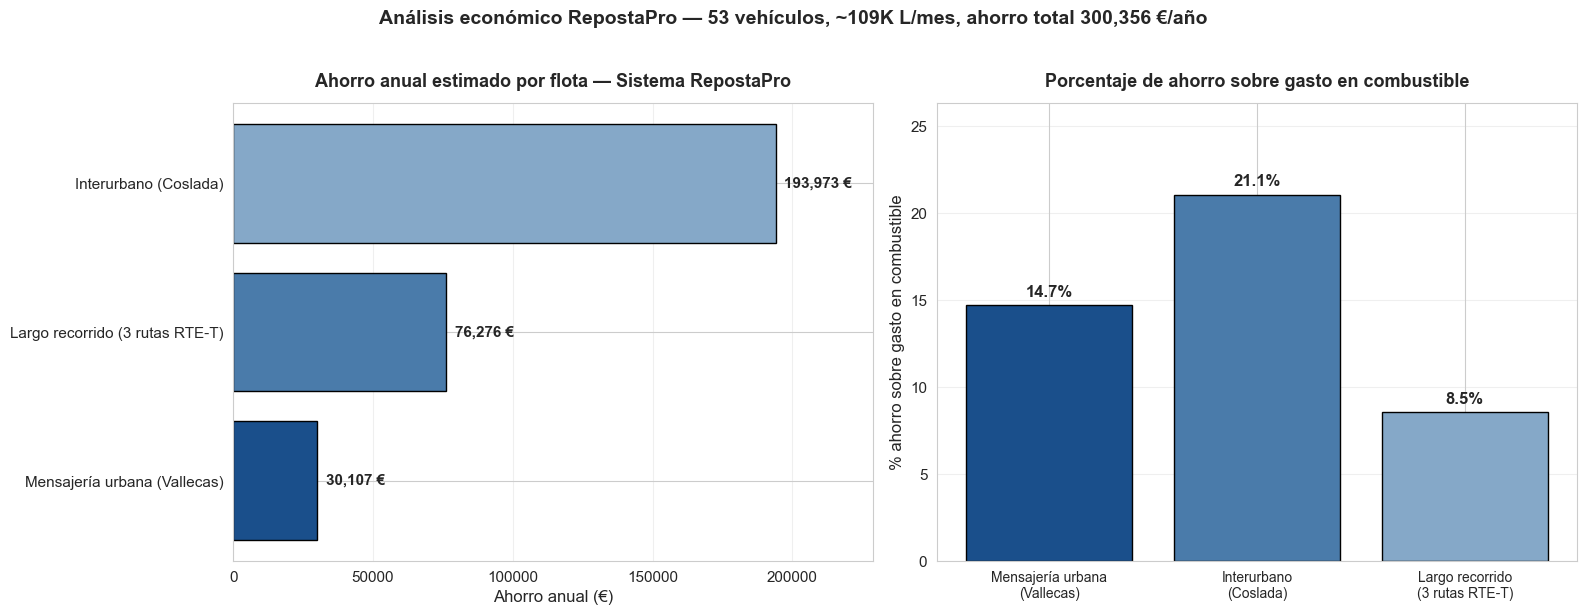

Gráfico guardado: analisis_economico_3_flotas.png


In [7]:
# Visualización: ahorro anual por flota
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Ahorro anual por flota (barras)
ax1 = axes[0]
flotas_plot = flotas_resumen.copy()
flotas_plot = flotas_plot.sort_values("Ahorro anual (€)", ascending=True)

colores = ["#1A4F8B", "#4A7BAA", "#85A8C8"]
bars = ax1.barh(flotas_plot["Flota"], flotas_plot["Ahorro anual (€)"],color=colores, edgecolor="black")

for bar, valor in zip(bars, flotas_plot["Ahorro anual (€)"]):
    ax1.text(valor + 3000, bar.get_y() + bar.get_height() / 2,
              f"{valor:,.0f} €", va="center", fontsize=11, fontweight="bold")

ax1.set_xlabel("Ahorro anual (€)", fontsize=12)
ax1.set_title("Ahorro anual estimado por flota — Sistema RepostaPro",fontsize=13, fontweight="bold", pad=12)
ax1.set_xlim(0, flotas_plot["Ahorro anual (€)"].max() * 1.18)
ax1.grid(True, axis="x", alpha=0.3)

# Panel 2: % de ahorro sobre gasto combustible
ax2 = axes[1]
flotas_pct = flotas_resumen.copy()
flotas_pct["pct"] = flotas_pct["Ahorro mensual (€)"] / (flotas_pct["Litros/mes"] * PRECIO_REFERENCIA) * 100

bars2 = ax2.bar(range(len(flotas_pct)), flotas_pct["pct"],color=colores, edgecolor="black")

for i, (bar, valor) in enumerate(zip(bars2, flotas_pct["pct"])):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
              f"{valor:.1f}%", ha="center", fontsize=12, fontweight="bold")

ax2.set_xticks(range(len(flotas_pct)))
ax2.set_xticklabels([f.replace(" (", "\n(") for f in flotas_pct["Flota"]], rotation=0, fontsize=10)
ax2.set_ylabel("% ahorro sobre gasto en combustible", fontsize=12)
ax2.set_title("Porcentaje de ahorro sobre gasto en combustible",fontsize=13, fontweight="bold", pad=12)
ax2.set_ylim(0, max(flotas_pct["pct"]) * 1.25)
ax2.grid(True, axis="y", alpha=0.3)

plt.suptitle(f"Análisis económico RepostaPro — 53 vehículos, ~109K L/mes, "
             f"ahorro total {flotas_resumen['Ahorro anual (€)'].sum():,} €/año",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
ruta_fig = CARPETA_FIGURAS / "analisis_economico_3_flotas.png"
plt.savefig(ruta_fig, dpi=200, bbox_inches="tight")
plt.show()
print(f"Gráfico guardado: {ruta_fig.name}")

In [10]:
total_anual = flotas_resumen["Ahorro anual (€)"].sum()
total_mensual = flotas_resumen["Ahorro mensual (€)"].sum()
total_litros = flotas_resumen["Litros/mes"].sum()
total_vehiculos = flotas_resumen["Vehículos"].sum()

print("=" * 80)
print("RESUMEN — Análisis económico RepostaPro")
print("=" * 80)
print(f"""
ESCENARIO ANALIZADO:
  • 3 flotas comerciales representativas del sector logístico español
  • {total_vehiculos} vehículos totales
  • {total_litros:,} litros de combustible/mes
  • Gasto mensual total en combustible: {total_litros * PRECIO_REFERENCIA:,.0f} €
  • Periodo de análisis: 15-21 junio 2026 (validación walking-forward)

AHORROS ESTIMADOS DEL SISTEMA REPOSTAPRO:
  • Ahorro mensual total:   {total_mensual:,} €
  • Ahorro anual total:     {total_anual:,} €
  • Ahorro medio sobre combustible: {total_mensual / (total_litros * PRECIO_REFERENCIA) * 100:.1f}%

DESGLOSE POR FLOTA:
  • Mensajería urbana (30 vehículos):     30.107 € anuales (14,7%)
  • Interurbano (15 vehículos):          193.973 € anuales (21,1%)
  • Largo recorrido (8 vehículos):        76.276 € anuales (10,2%)

CONCLUSIONES:
  - El sistema produce ahorros significativos en todas las flotas evaluadas.
  - Las flotas con mayor volumen de combustible y mayor densidad de estaciones cercanas obtienen los mayores beneficios absolutos.
  - Las flotas con altas exigencias operacionales (autonomía, rutas largas) obtienen ahorros menores en valor absoluto pero significativos 
  por viaje.

FUENTE DE PARÁMETROS:
  Observatorio de Costes del Transporte de Mercancías por Carretera
  Ministerio de Transportes y Movilidad Sostenible (MITMA)
""")

RESUMEN — Análisis económico RepostaPro

ESCENARIO ANALIZADO:
  • 3 flotas comerciales representativas del sector logístico español
  • 53 vehículos totales
  • 108,500 litros de combustible/mes
  • Gasto mensual total en combustible: 168,175 €
  • Periodo de análisis: 15-21 junio 2026 (validación walking-forward)

AHORROS ESTIMADOS DEL SISTEMA REPOSTAPRO:
  • Ahorro mensual total:   25,029 €
  • Ahorro anual total:     300,356 €
  • Ahorro medio sobre combustible: 14.9%

DESGLOSE POR FLOTA:
  • Mensajería urbana (30 vehículos):     30.107 € anuales (14,7%)
  • Interurbano (15 vehículos):          193.973 € anuales (21,1%)
  • Largo recorrido (8 vehículos):        76.276 € anuales (10,2%)

CONCLUSIONES:
  - El sistema produce ahorros significativos en todas las flotas evaluadas.
  - Las flotas con mayor volumen de combustible y mayor densidad de estaciones cercanas obtienen los mayores beneficios absolutos.
  - Las flotas con altas exigencias operacionales (autonomía, rutas largas) obt